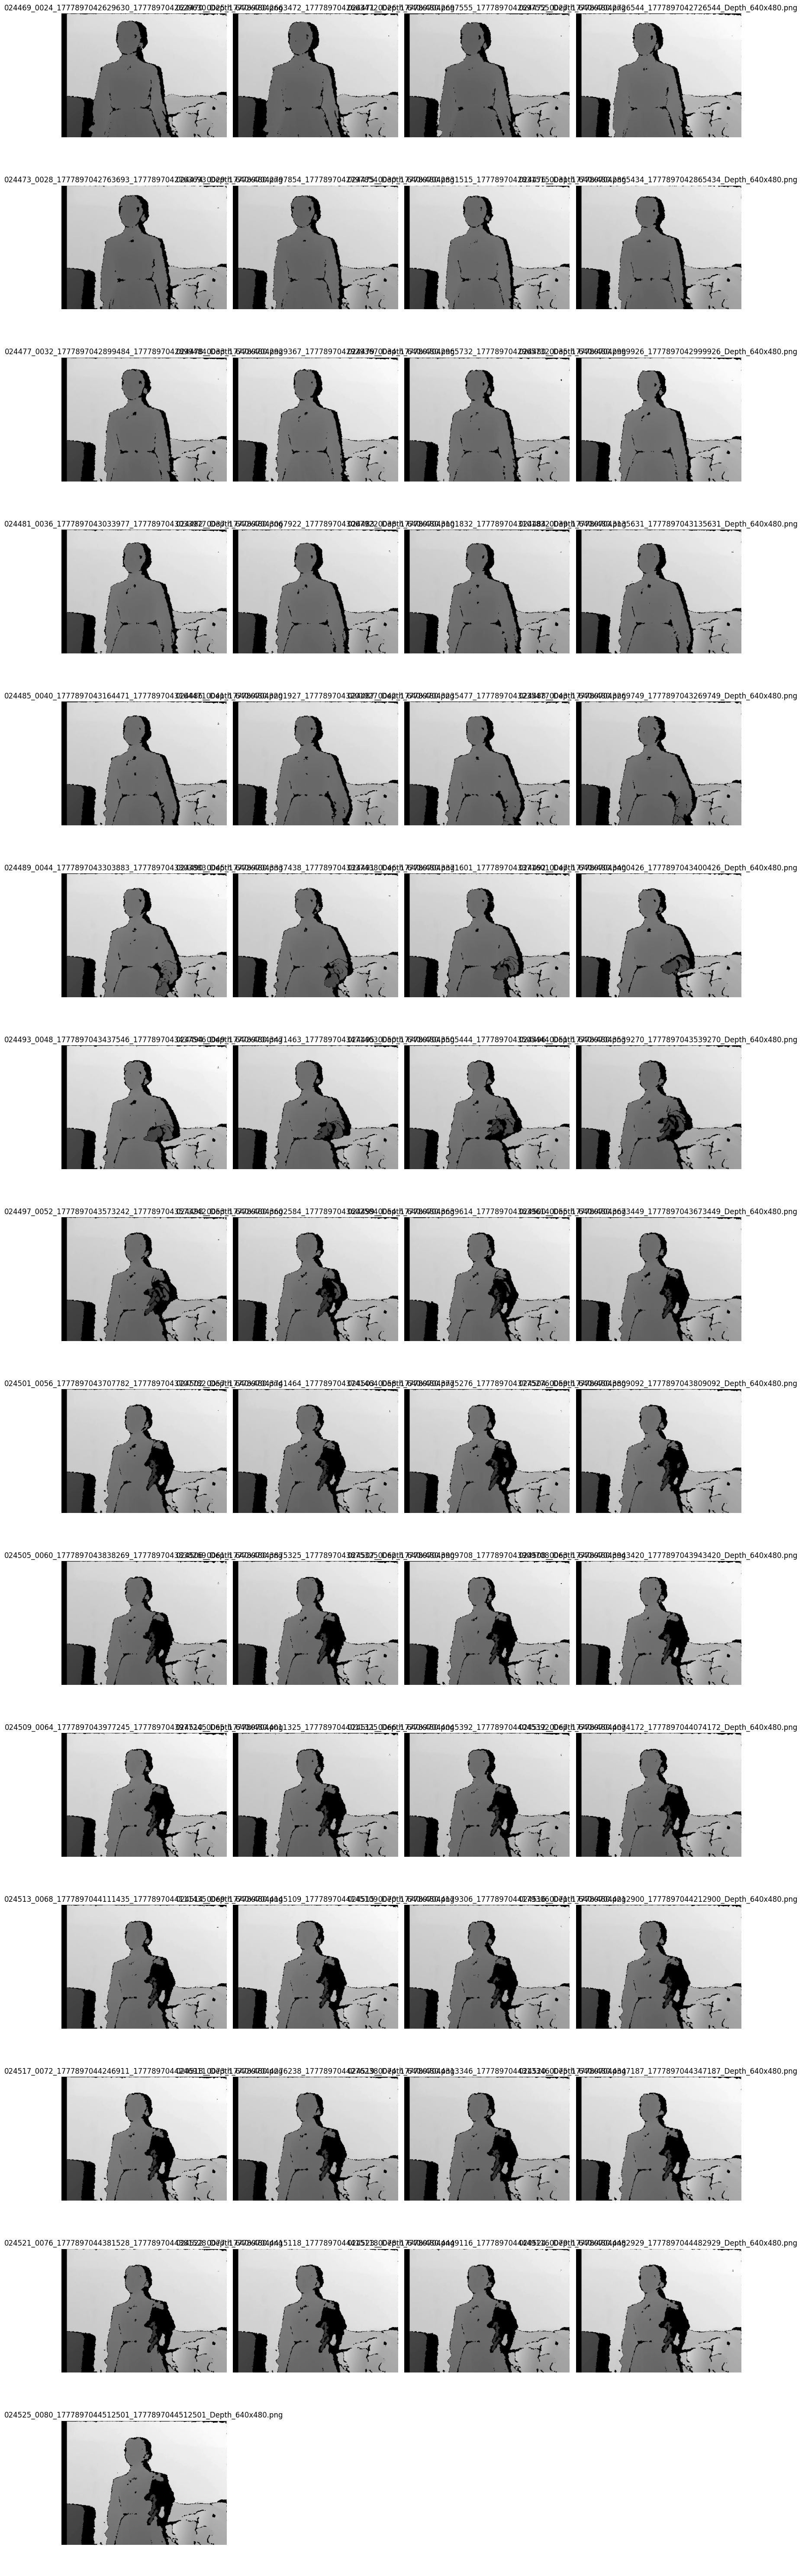

In [14]:
from pathlib import Path
from PIL import Image
import math

import matplotlib.pyplot as plt

# from Xth to Yth image (inclusive)
start_id = 24   # e.g. 0000
end_id = 80     # e.g. 0089

data_dir = Path("./customDataset/handReaching/0504_2017_90")
# data_dir = Path("./customDataset/stationary/0504_0007_80")
# data_dir = Path("./customDataset/other/0504_0204_90")

# Collect matching image files
image_files = []
for p in sorted(data_dir.iterdir()):
    if p.is_file():
        name = p.stem  # filename without extension
        prefix = name[8:11]
        if prefix.isdigit():
            file_id = int(prefix)
            if start_id <= file_id <= end_id:
                image_files.append(p)

if not image_files:
    print("No matching images found.")
else:
    n = len(image_files)
    cols = min(4, n)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = [axes] if n == 1 else axes.flatten()

    for ax, img_path in zip(axes, image_files):
        img = Image.open(img_path)
        ax.imshow(img, cmap="gray")
        ax.set_title(img_path.name)
        ax.axis("off")

    for ax in axes[len(image_files):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()